In [63]:
import requests
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from datetime import datetime

In [64]:
load_dotenv()
WAQI_TOKEN = os.getenv("WAQI_TOKEN")

In [65]:
LAT, LON = 30.1978 , 71.4719

## AQICN

In [66]:
# url = f"https://api.waqi.info/feed/multan/?token={WAQI_TOKEN}"
# response = requests.get(url)
# data = response.json()

# print(data)

In [67]:
# station_ids = {
#     "Women University": "A544288",
#     "District Officer Industries": "A544444",
#     "BZU Multan": "A576622",
#     "Walled Cities Authority": "A544066"
# }

# for name, station_id in station_ids.items():
#     url = f"https://api.waqi.info/feed/{station_id}/?token={WAQI_TOKEN}"
#     resp = requests.get(url).json()
#     if resp["status"] == "ok":
#         aqi = resp["data"].get("aqi", "N/A")
#         time = resp["data"]["time"]["s"]
#         print(f"{name}: AQI={aqi}, last reported={time}")
#     else:
#         print(f"{name}: ERROR - {resp}")

In [68]:
# url = f"https://api.waqi.info/feed/A544288/?token={WAQI_TOKEN}"
# response = requests.get(url)
# data = response.json()
# print(data)

In [69]:
# url = f"https://api.waqi.info/feed/A544288/?token={WAQI_TOKEN}"
# resp = requests.get(url).json()

# data = resp["data"]
# iaqi = data["iaqi"]  # nested dict of individual pollutants

# flat = {"aqi": data["aqi"], "timestamp": data["time"]["s"]}
# for pollutant, val in iaqi.items():
#     flat[pollutant] = val["v"]

# print(flat)

**Decision: AQICN/WAQI dropped.** The WAQI API was explored first since it's a well-known free AQI source, but station coverage for Multan proved unreliable. geo-lookup for the city returned a station in Dushanbe, Tajikistan instead of a local one, and the manually-listed Multan station IDs above were inconsistent in availability. Open-Meteo was adopted instead because it provides coordinate-based weather *and* air-quality data (no dependency on a physical station being online), covering both needs from a single, more reliable provider.

## Open Meteo

In [70]:
url = "https://api.open-meteo.com/v1/forecast"
params = {
    "latitude": LAT,
    "longitude": LON,
    "current": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
print(resp)

{'latitude': 30.193321, 'longitude': 71.47369, 'generationtime_ms': 21.379947662353516, 'utc_offset_seconds': 18000, 'timezone': 'Asia/Karachi', 'timezone_abbreviation': 'GMT+5', 'elevation': 143.0, 'current_units': {'time': 'iso8601', 'interval': 'seconds', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'wind_speed_10m': 'km/h', 'surface_pressure': 'hPa', 'cloud_cover': '%', 'precipitation': 'mm'}, 'current': {'time': '2026-09-05T01:00', 'interval': 900, 'temperature_2m': 33.3, 'relative_humidity_2m': 47, 'wind_speed_10m': 3.6, 'surface_pressure': 988.1, 'cloud_cover': 9, 'precipitation': 0.0}}


In [71]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2023-09-05",
    "end_date": "2026-09-04",
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
df_weather = pd.DataFrame(resp["hourly"])

df_weather.head()

,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation
0,2023-09-05T00:00,27.1,75,8.8,985.8,0,0.0
1,2023-09-05T01:00,27.5,70,6.8,985.7,0,0.0
2,2023-09-05T02:00,27.2,70,7.7,985.8,0,0.0
3,2023-09-05T03:00,27.2,71,9.1,985.9,0,0.0
4,2023-09-05T04:00,27.2,71,10.3,986.0,0,0.0


In [72]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LAT,
    "longitude": LON,
    "current": "us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust,ammonia",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
print(resp["current"])

{'time': '2026-09-05T01:00', 'interval': 3600, 'us_aqi': 84, 'pm2_5': 36.7, 'pm10': 60.8, 'carbon_monoxide': 430.0, 'nitrogen_dioxide': 10.7, 'sulphur_dioxide': 7.0, 'ozone': 55.0, 'dust': 43.0, 'ammonia': None}


In [73]:
url = "https://air-quality-api.open-meteo.com/v1/air-quality"
params = {
    "latitude": LAT,
    "longitude": LON,
    "start_date": "2023-09-05",
    "end_date": "2026-09-04",
    "hourly": "us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust",
    "timezone": "Asia/Karachi"
}

resp = requests.get(url, params=params).json()
df_aqi = pd.DataFrame(resp["hourly"])

df_aqi.head()

,time,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust
0,2023-09-05T00:00,88,44.1,68.2,970.0,49.3,6.6,17.0,28.0
1,2023-09-05T01:00,87,35.9,61.5,763.0,37.5,5.0,25.0,50.0
2,2023-09-05T02:00,86,32.4,70.5,582.0,27.7,3.8,31.0,69.0
3,2023-09-05T03:00,87,31.7,88.7,470.0,22.7,3.2,31.0,85.0
4,2023-09-05T04:00,87,29.8,92.4,384.0,19.7,3.0,30.0,99.0


In [74]:
print(df_weather.shape)
print(df_weather.isnull().sum())

print(df_aqi.shape)
print(df_aqi.isnull().sum())

(26304, 7)
time                    0
temperature_2m          0
relative_humidity_2m    0
wind_speed_10m          0
surface_pressure        0
cloud_cover             0
precipitation           0
dtype: int64
(26304, 9)
time                0
us_aqi              0
pm2_5               0
pm10                0
carbon_monoxide     0
nitrogen_dioxide    0
sulphur_dioxide     0
ozone               0
dust                0
dtype: int64


## Merging

In [75]:
df_merged = pd.merge(df_weather, df_aqi, on="time", how="inner")
print(df_merged.shape)
df_merged.head()

(26304, 15)


,time,temperature_2m,relative_humidity_2m,wind_speed_10m,surface_pressure,cloud_cover,precipitation,us_aqi,pm2_5,pm10,carbon_monoxide,nitrogen_dioxide,sulphur_dioxide,ozone,dust
0,2023-09-05T00:00,27.1,75,8.8,985.8,0,0.0,88,44.1,68.2,970.0,49.3,6.6,17.0,28.0
1,2023-09-05T01:00,27.5,70,6.8,985.7,0,0.0,87,35.9,61.5,763.0,37.5,5.0,25.0,50.0
2,2023-09-05T02:00,27.2,70,7.7,985.8,0,0.0,86,32.4,70.5,582.0,27.7,3.8,31.0,69.0
3,2023-09-05T03:00,27.2,71,9.1,985.9,0,0.0,87,31.7,88.7,470.0,22.7,3.2,31.0,85.0
4,2023-09-05T04:00,27.2,71,10.3,986.0,0,0.0,87,29.8,92.4,384.0,19.7,3.0,30.0,99.0


In [76]:
df_merged["time"] = pd.to_datetime(df_merged["time"])
df_merged = df_merged.sort_values("time")

## Validation

In [77]:
print(df_merged.describe())

                      time  temperature_2m  relative_humidity_2m  \
count                26304    26304.000000          26304.000000   
mean   2025-03-05 23:30:00       26.410706             53.893020   
min    2023-09-05 00:00:00        3.100000              4.000000   
25%    2024-06-04 23:45:00       19.400000             38.000000   
50%    2025-03-05 23:30:00       27.800000             53.000000   
75%    2025-12-04 23:15:00       33.600000             70.000000   
max    2026-09-04 23:00:00       47.100000            100.000000   
std                    NaN        9.133088             21.955194   

       wind_speed_10m  surface_pressure   cloud_cover  precipitation  \
count    26304.000000      26304.000000  26304.000000   26304.000000   
mean         8.081068        991.527836     23.345651       0.028631   
min          0.000000        972.400000      0.000000       0.000000   
25%          5.200000        984.900000      0.000000       0.000000   
50%          7.700000      

In [78]:
print(df_merged.columns.tolist())

['time', 'temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 'surface_pressure', 'cloud_cover', 'precipitation', 'us_aqi', 'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 'sulphur_dioxide', 'ozone', 'dust']


In [79]:
df_merged.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
26299    False
26300    False
26301    False
26302    False
26303    False
Length: 26304, dtype: bool

## Visualization

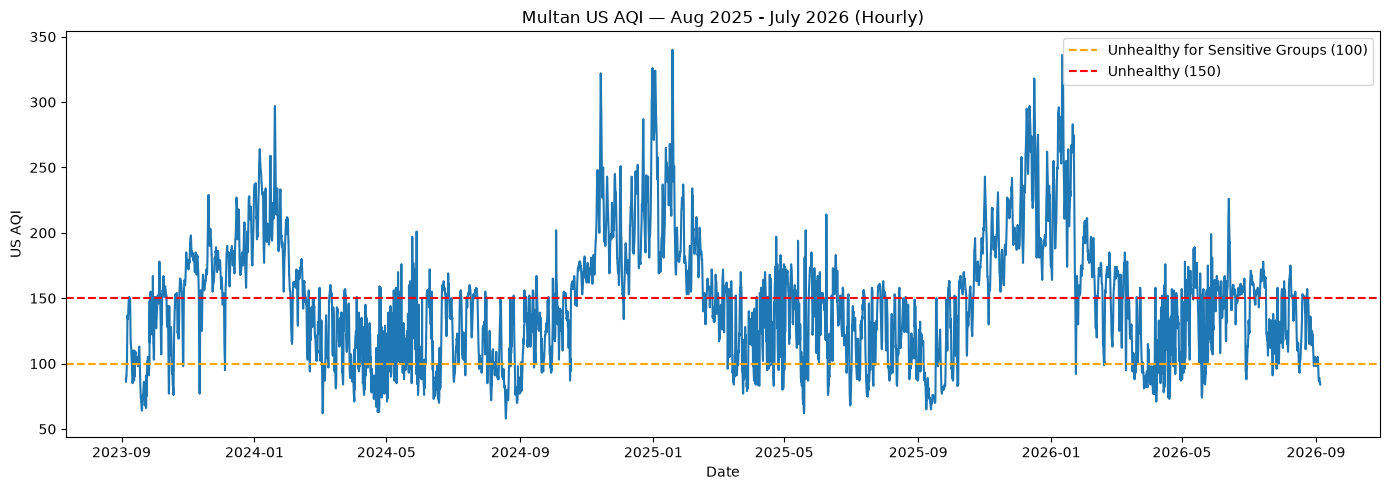

In [80]:
plt.figure(figsize=(14, 5))
plt.plot(df_merged["time"], df_merged["us_aqi"])
plt.title("Multan US AQI — Aug 2025 - July 2026 (Hourly)")
plt.xlabel("Date")
plt.ylabel("US AQI")
plt.axhline(y=100, color='orange', linestyle='--', label='Unhealthy for Sensitive Groups (100)')
plt.axhline(y=150, color='red', linestyle='--', label='Unhealthy (150)')
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x500 with 0 Axes>

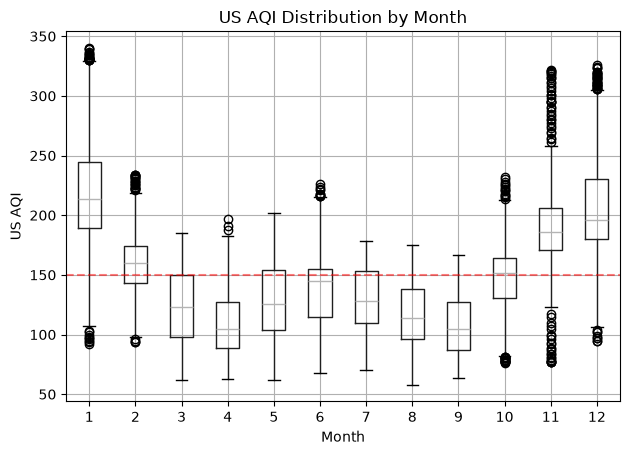

In [81]:
df_merged["month"] = df_merged["time"].dt.month

plt.figure(figsize=(12, 5))
df_merged.boxplot(column="us_aqi", by="month")
plt.title("US AQI Distribution by Month")
plt.suptitle("")
plt.xlabel("Month")
plt.ylabel("US AQI")
plt.axhline(y=150, color='red', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

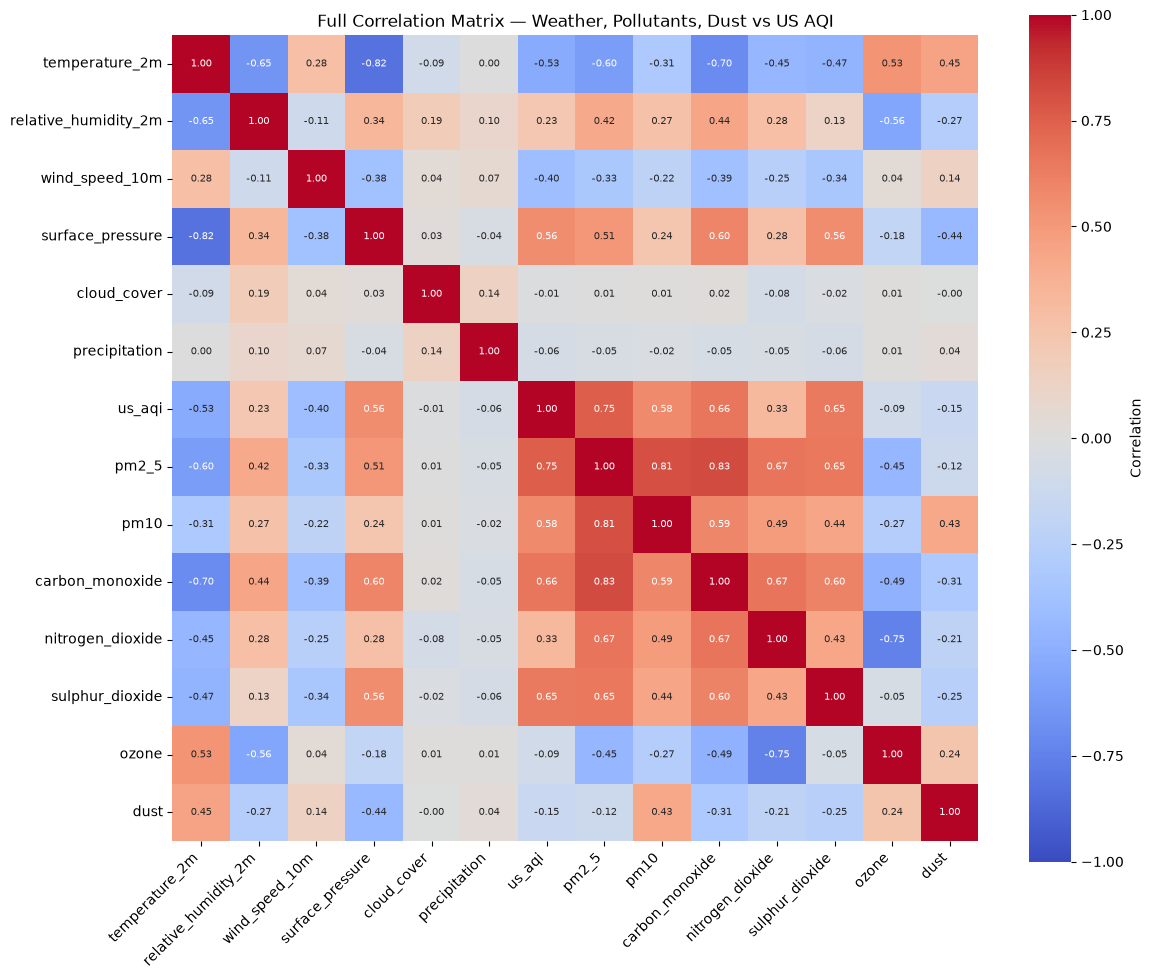

In [82]:
corr_cols = ['temperature_2m', 'relative_humidity_2m', 'wind_speed_10m', 
             'surface_pressure', 'cloud_cover', 'precipitation', 'us_aqi', 
             'pm2_5', 'pm10', 'carbon_monoxide', 'nitrogen_dioxide', 
             'sulphur_dioxide', 'ozone', 'dust']

corr_matrix = df_merged[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
            square=True, cbar_kws={"label": "Correlation"}, annot_kws={"size": 7})
plt.title("Full Correlation Matrix — Weather, Pollutants, Dust vs US AQI")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

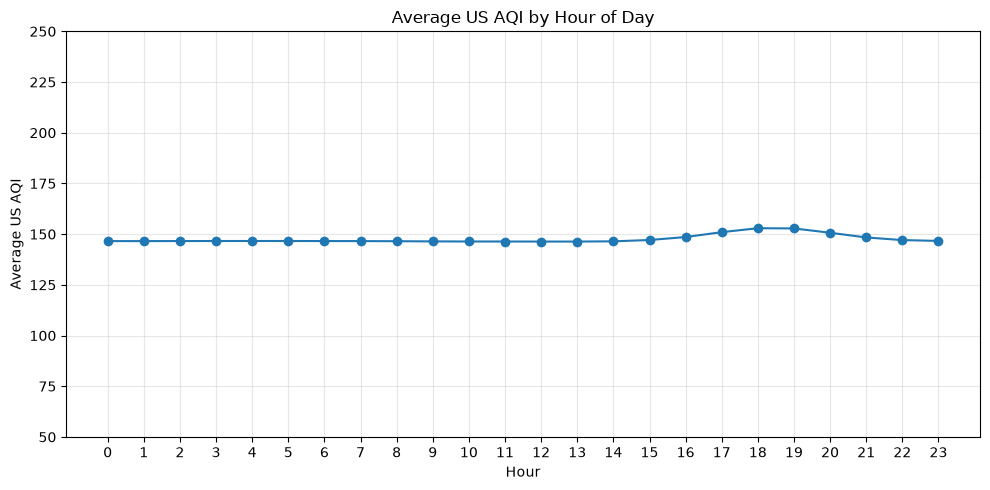

In [83]:
df_merged["hour"] = df_merged["time"].dt.hour

hourly_avg = df_merged.groupby("hour")["us_aqi"].mean()

plt.figure(figsize=(10, 5))
hourly_avg.plot(kind="line", marker="o")
plt.title("Average US AQI by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average US AQI")
plt.ylim(50, 250)
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Investigation the outliers in June

In [84]:
def flag_outliers(group):
    q1, q3 = group["us_aqi"].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    group = group.copy()
    group["is_outlier"] = (group["us_aqi"] < lower) | (group["us_aqi"] > upper)
    group["direction"] = np.select(
        [group["us_aqi"] > upper, group["us_aqi"] < lower],
        ["high", "low"],
        default="none"
    )
    return group

df_flagged = df_merged.groupby("month", group_keys=False).apply(flag_outliers)

C:\Users\dawoo\AppData\Local\Temp\ipykernel_6700\1326619139.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_flagged = df_merged.groupby("month", group_keys=False).apply(flag_outliers)


In [85]:
summary = (
    df_flagged[df_flagged["is_outlier"]]
    .groupby(["month", "direction"])
    .size()
    .unstack(fill_value=0)
)
print(summary)

direction  high  low
month               
1            22    9
2            22    4
4             3    0
6            10    0
10           14   19
11           36   23
12           34    8


In [86]:
winter_highs = df_flagged[
    (df_flagged["direction"] == "high") & (df_flagged["month"].isin([11, 12, 1]))
]
print(f"Winter (Nov/Dec/Jan) high-side outlier hours: {len(winter_highs)}")
print(winter_highs["us_aqi"].describe())

Winter (Nov/Dec/Jan) high-side outlier hours: 92
count     92.000000
mean     311.369565
std       19.145893
min      261.000000
25%      305.500000
50%      314.500000
75%      324.500000
max      340.000000
Name: us_aqi, dtype: float64


In [87]:
low_outliers = df_flagged[
    (df_flagged["direction"] == "low") & (df_flagged["month"].isin([2, 9, 10, 11]))
].sort_values("time")

# group consecutive low-outlier hours into distinct events
low_outliers["gap"] = low_outliers["time"].diff().dt.total_seconds().div(3600).fillna(999)
low_outliers["event_id"] = (low_outliers["gap"] > 6).cumsum()

low_events = low_outliers.groupby("event_id").agg(
    start=("time", "min"), end=("time", "max"),
    duration_h=("time", "count"),
    min_aqi=("us_aqi", "min"),
    max_wind=("wind_speed_10m", "max"),
    max_dust=("dust", "max"),
    max_precip=("precipitation", "max"),
).reset_index(drop=True)

print(f"Distinct low-AQI (dispersal candidate) events: {len(low_events)}")
print(low_events.sort_values("start").to_string(index=False))

Distinct low-AQI (dispersal candidate) events: 4
              start                 end  duration_h  min_aqi  max_wind  max_dust  max_precip
2023-10-14 07:00:00 2023-10-14 14:00:00           8       77      15.7      10.0         0.0
2023-10-18 09:00:00 2023-10-18 19:00:00          11       76       7.6      28.0         0.0
2023-11-11 03:00:00 2023-11-12 01:00:00          23       77       9.1       3.0         0.0
2024-02-20 17:00:00 2024-02-20 20:00:00           4       94      10.1     189.0         0.0


In [88]:
cols = ["time", "us_aqi", "temperature_2m", "relative_humidity_2m",
        "surface_pressure", "wind_speed_10m", "dust", "cloud_cover"]

for _, ev in low_events.sort_values("start").iterrows():
    pad = pd.Timedelta(hours=6)
    w = df_merged[(df_merged["time"] >= ev["start"] - pad) & (df_merged["time"] <= ev["end"] + pad)]
    print(f"\n=== Event {ev['start']} to {ev['end']} ===")
    print(w[cols].to_string(index=False))


=== Event 2023-10-14 07:00:00 to 2023-10-14 14:00:00 ===
               time  us_aqi  temperature_2m  relative_humidity_2m  surface_pressure  wind_speed_10m  dust  cloud_cover
2023-10-14 01:00:00     101            26.3                    46             992.5            12.3  19.0            0
2023-10-14 02:00:00      97            26.2                    44             992.0            14.1  23.0            0
2023-10-14 03:00:00      92            27.0                    39             992.0            17.8  19.0            0
2023-10-14 04:00:00      88            27.3                    39             992.1            17.6  12.0            0
2023-10-14 05:00:00      84            27.3                    42             992.1            18.4   6.0            0
2023-10-14 06:00:00      83            26.5                    47             992.7            15.6   6.0            0
2023-10-14 07:00:00      81            26.0                    52             993.8            11.0   7.0    

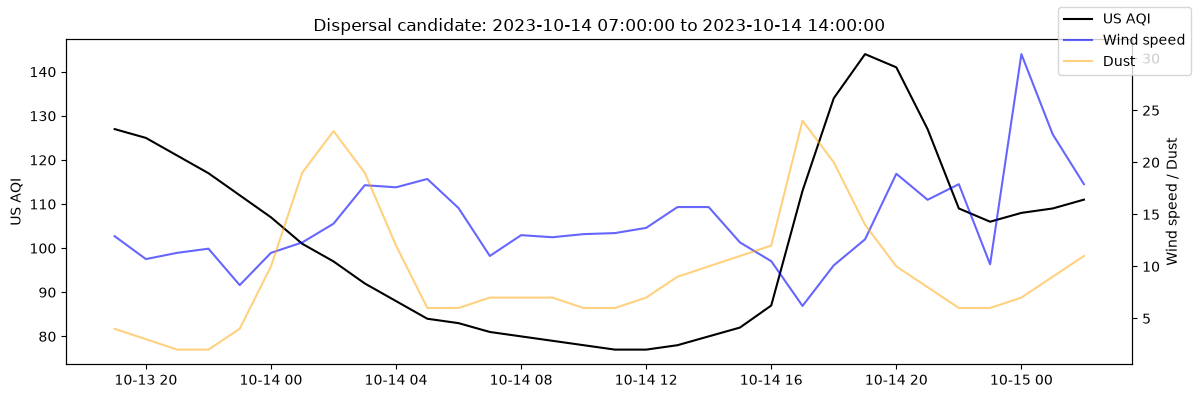

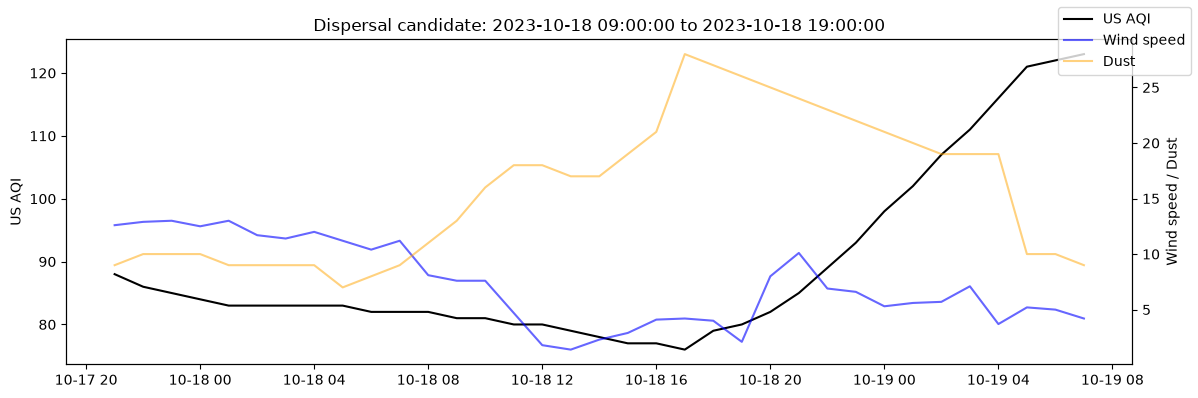

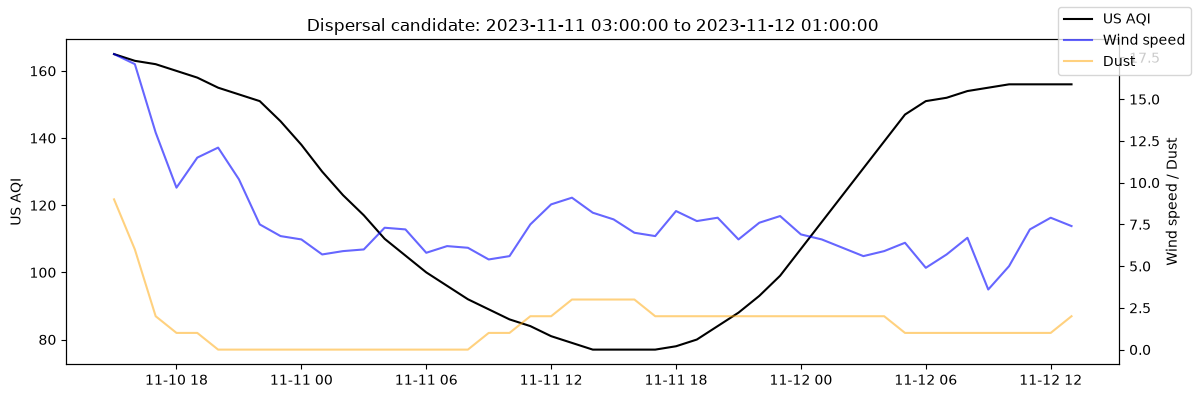

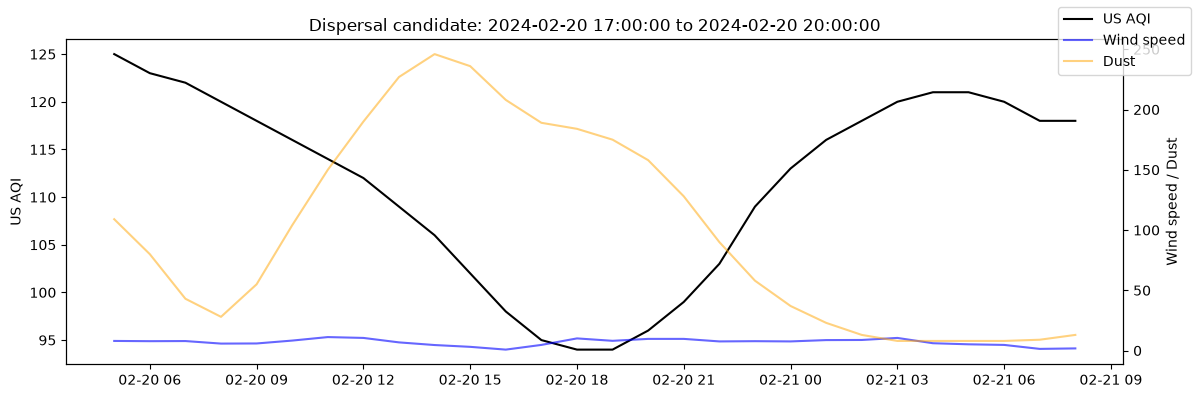

In [89]:
for _, ev in low_events.sort_values("start").iterrows():
    pad = pd.Timedelta(hours=12)
    w = df_merged[(df_merged["time"] >= ev["start"] - pad) & (df_merged["time"] <= ev["end"] + pad)]

    fig, ax1 = plt.subplots(figsize=(12, 4))
    ax1.plot(w["time"], w["us_aqi"], color="black", label="US AQI")
    ax1.set_ylabel("US AQI")
    ax2 = ax1.twinx()
    ax2.plot(w["time"], w["wind_speed_10m"], color="blue", alpha=0.6, label="Wind speed")
    ax2.plot(w["time"], w["dust"], color="orange", alpha=0.5, label="Dust")
    ax2.set_ylabel("Wind speed / Dust")
    fig.legend(loc="upper right")
    plt.title(f"Dispersal candidate: {ev['start']} to {ev['end']}")
    plt.tight_layout()
    plt.show()

## Outlier investigation — conclusions

Per-month IQR flagging (rather than a single pooled threshold) surfaces three distinct
patterns, not one:

**1. Winter high-side outliers (Nov/Dec/Jan, 92 hours, mean AQI 311, range 261–340)**
are not standalone anomalies — they are the extreme tail of an already-severe season
(crop-burning + temperature inversion). No separate mechanism needed here; they're
summarized statistically rather than investigated event-by-event.

**2. The June 12–13 spike (10 hours, AQI up to 226, dust up to 482)** is a genuine,
isolated anomaly: a dust-storm suspension event with no counterpart elsewhere in the
dataset.

**3. Three of the four low-AQI outliers (Oct 14 2023, Oct 18 2023, Nov 11–12 2023)**
were hypothesized to reflect wind-driven dispersal, but the data doesn't support that:
wind speed is unremarkable during these dips, and in the Oct 18 case it actually drops
to near-zero right at the AQI trough. Instead, each dip lines up with the hottest,
driest part of the day and reverses overnight — this is ordinary **diurnal
boundary-layer mixing** (daytime heating deepens the mixing layer and dilutes surface
pollutants; nighttime cooling traps them again), consistent with the hour-of-day
average AQI pattern shown earlier in this notebook. These are amplified instances of a
normal daily cycle, not a distinct anomaly type.

**4. The fourth low-AQI outlier (Feb 20 2024)** doesn't fit the diurnal-mixing pattern —
dust stays elevated (150–246) even as AQI falls, alongside a sharp temperature drop
(22.7°C → 13.9°C) consistent with a cold-front passage bringing in cleaner air while a
residual dust layer had not yet cleared. Treated as a single unexplained edge case
rather than a recurring mechanism, and flagged here for transparency rather than
built into a broader narrative.

**Takeaway for feature engineering / modeling:** the diurnal-mixing finding reinforces
the value of hour-of-day cyclical features and lag features already included; the
June event and the Feb 20 case are rare enough that no dedicated feature was
engineered for them specifically, but they're documented here as known limitations
of what the model can be expected to anticipate.

In [90]:
df_merged.to_csv(r"..\Data\sample_data.csv",index=False)